In [3]:
import datetime
import math
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
import requests

from utilities.loaders import partition_signals_per_hour, charge_raw_data, get_time_frequency

from utilities.preprocessors import (which_element,
    find_begin_end,
    interpolate_signals,
    butter_lowpass_filter,
    load_wavelet_data, 
    restructure_wavelets, 
    compute_features)

from utilities.visualizers import (view_time_frame,
    view_wavelet_coeffs,
    analyze,
    data_split_metric_values,
    view_value_frequency,
    multi_class_heatmap,
    view_metric_values,
    view_classified_labels,
    view_label_freq,
    disp_cat_feat,
    plot_all_features,
    describe_col,
    ModelResults,
    view_all_splits_results)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Downloading dataset

If your project requires downloading a larger file, then you may run into issues using the steps above when you try to load the entire file into memory. To overcome those issues, you can download large files in a streaming fashion to avoid reading the content of large responses all at once

In [4]:
response = requests.get("https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/w8fxrg4pv5-2.zip", stream=True)
response.headers

{'x-amz-id-2': 'jkuDaXg4i8slnQpmXs0h1gkdblG1HS7VFErfJkz+Oe2T9c0EV6sSxv3omBqDGG8EjmKRPL+fjGU=', 'x-amz-request-id': 'VJ4EPZE4AMV0RAR1', 'Date': 'Wed, 17 Jul 2024 08:29:07 GMT', 'Last-Modified': 'Thu, 15 Jun 2023 12:16:03 GMT', 'ETag': '"9c1286960ffe2050326d47416f454cbd-12"', 'x-amz-storage-class': 'INTELLIGENT_TIERING', 'x-amz-server-side-encryption': 'AES256', 'Content-Disposition': "attachment; filename*=UTF-8''Electrodermal%20Activity%20artifact%20correction%20BEnchmark%20%28EDABE%29.zip", 'x-amz-version-id': 'null', 'Accept-Ranges': 'bytes', 'Content-Type': 'application/zip', 'Server': 'AmazonS3', 'Content-Length': '246889708'}

In [5]:
with open("./data/EDABE dataset.zip", mode="wb") as file:
    for chunk in response.iter_content(chunk_size=10 * 1024):
        file.write(chunk)

In [6]:
# Extract data from zip file
with zipfile.ZipFile('./data/EDABE dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('./data')

# Loading dataset

In [7]:
# Extract data from zip file
with zipfile.ZipFile('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/EDABE dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)')

In [10]:
ahixac_eda_df_128hz = pd.read_csv('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)/Train/ahixac_expert1.csv', sep=';')
ahixac_eda_df_128hz

,time,rawdata,cleandata,binarytarget,signal_automatic,PredArtifacts,PostProcessedPredArtifacts
0,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1,0.007812,0.000000,-0.127567,0.0,1.879714e-06,1.0,1.0
2,0.015625,0.000000,-0.127567,0.0,3.656027e-06,1.0,1.0
3,0.023438,0.000000,-0.127567,0.0,5.370973e-06,1.0,1.0
4,0.031250,0.000000,-0.127567,0.0,7.062509e-06,1.0,1.0
...,...,...,...,...,...,...,...
832825,6506.445312,2.591209,2.591209,0.0,2.591209e+00,0.0,0.0
832826,6506.453125,2.585348,2.585348,0.0,2.585348e+00,0.0,0.0
832827,6506.460938,2.602930,2.602930,0.0,2.602930e+00,0.0,0.0
832828,6506.468750,2.570696,2.570696,0.0,2.570696e+00,0.0,0.0


In [11]:
ahixac_eda_df_128hz.columns = ['time', 'raw_signal', 'clean_signal', 'label', 'auto_signal', 'pred_art', 'post_proc_pred_art']

In [12]:
start_time = ahixac_eda_df_128hz.iloc[0]['time']
start_time

0.0

In [13]:
ahixac_eda_df_128hz.set_index(pd.date_range(start=start_time, periods=ahixac_eda_df_128hz.shape[0], freq=get_time_frequency(128)), inplace=True)
ahixac_eda_df_128hz

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art
1970-01-01 00:00:00.000000000,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1970-01-01 00:00:00.007812500,0.007812,0.000000,-0.127567,0.0,1.879714e-06,1.0,1.0
1970-01-01 00:00:00.015625000,0.015625,0.000000,-0.127567,0.0,3.656027e-06,1.0,1.0
1970-01-01 00:00:00.023437500,0.023438,0.000000,-0.127567,0.0,5.370973e-06,1.0,1.0
1970-01-01 00:00:00.031250000,0.031250,0.000000,-0.127567,0.0,7.062509e-06,1.0,1.0
...,...,...,...,...,...,...,...
1970-01-01 01:48:26.445312500,6506.445312,2.591209,2.591209,0.0,2.591209e+00,0.0,0.0
1970-01-01 01:48:26.453125000,6506.453125,2.585348,2.585348,0.0,2.585348e+00,0.0,0.0
1970-01-01 01:48:26.460937500,6506.460938,2.602930,2.602930,0.0,2.602930e+00,0.0,0.0
1970-01-01 01:48:26.468750000,6506.468750,2.570696,2.570696,0.0,2.570696e+00,0.0,0.0


# Downsampling 128hz signals to 16hz

In [14]:
ahixac_eda_df_16hz = interpolate_signals(ahixac_eda_df_128hz, sample_rate=128, start_time=start_time, target_hz=16)
ahixac_eda_df_16hz

62.5ms


,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art
1970-01-01 00:00:00.000000,0.0000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0
1970-01-01 00:00:00.062500,0.0625,0.000000,-0.022974,0.0,1.357508e-05,1.0,1.0
1970-01-01 00:00:00.125000,0.1250,0.000000,-0.022974,0.0,2.747785e-05,1.0,1.0
1970-01-01 00:00:00.187500,0.1875,0.000000,-0.005128,0.0,5.611462e-05,1.0,1.0
1970-01-01 00:00:00.250000,0.2500,0.000222,0.000222,0.0,1.260593e-04,1.0,1.0
...,...,...,...,...,...,...,...
1970-01-01 01:48:26.187500,6506.1875,2.547253,2.547253,0.0,2.547253e+00,0.0,0.0
1970-01-01 01:48:26.250000,6506.2500,2.554579,2.554579,0.0,2.554579e+00,0.0,0.0
1970-01-01 01:48:26.312500,6506.3125,2.594139,2.594139,0.0,2.594139e+00,0.0,0.0
1970-01-01 01:48:26.375000,6506.3750,2.592674,2.592674,0.0,2.592674e+00,0.0,0.0


# Low-pass filtering raw 128hz and 16hz signals 

In [16]:
ahixac_eda_df_128hz['filtered_signal'] = butter_lowpass_filter(ahixac_eda_df_128hz['raw_signal'], cutoff=1.0, samp_freq=128, order=6)
ahixac_eda_df_16hz['filtered_signal'] = butter_lowpass_filter(ahixac_eda_df_16hz['raw_signal'], cutoff=1.0, samp_freq=16, order=6)

C:\Users\Mig\AppData\Local\Temp\ipykernel_4728\3441688614.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ahixac_eda_df_16hz['filtered_signal'] = butter_lowpass_filter(ahixac_eda_df_16hz['raw_signal'], cutoff=1.0, samp_freq=16, order=6)


In [17]:
ahixac_eda_df_128hz

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art,filtered_signal
1970-01-01 00:00:00.000000000,0.000000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0,0.000000
1970-01-01 00:00:00.007812500,0.007812,0.000000,-0.127567,0.0,1.879714e-06,1.0,1.0,0.000000
1970-01-01 00:00:00.015625000,0.015625,0.000000,-0.127567,0.0,3.656027e-06,1.0,1.0,0.000000
1970-01-01 00:00:00.023437500,0.023438,0.000000,-0.127567,0.0,5.370973e-06,1.0,1.0,0.000000
1970-01-01 00:00:00.031250000,0.031250,0.000000,-0.127567,0.0,7.062509e-06,1.0,1.0,0.000000
...,...,...,...,...,...,...,...,...
1970-01-01 01:48:26.445312500,6506.445312,2.591209,2.591209,0.0,2.591209e+00,0.0,0.0,2.610662
1970-01-01 01:48:26.453125000,6506.453125,2.585348,2.585348,0.0,2.585348e+00,0.0,0.0,2.609485
1970-01-01 01:48:26.460937500,6506.460938,2.602930,2.602930,0.0,2.602930e+00,0.0,0.0,2.608305
1970-01-01 01:48:26.468750000,6506.468750,2.570696,2.570696,0.0,2.570696e+00,0.0,0.0,2.607123


In [18]:
ahixac_eda_df_16hz

,time,raw_signal,clean_signal,label,auto_signal,pred_art,post_proc_pred_art,filtered_signal
1970-01-01 00:00:00.000000,0.0000,0.000000,-0.164015,0.0,2.106994e-20,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.062500,0.0625,0.000000,-0.022974,0.0,1.357508e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.125000,0.1250,0.000000,-0.022974,0.0,2.747785e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.187500,0.1875,0.000000,-0.005128,0.0,5.611462e-05,1.0,1.0,0.000000e+00
1970-01-01 00:00:00.250000,0.2500,0.000222,0.000222,0.0,1.260593e-04,1.0,1.0,6.399354e-09
...,...,...,...,...,...,...,...,...
1970-01-01 01:48:26.187500,6506.1875,2.547253,2.547253,0.0,2.547253e+00,0.0,0.0,2.627107e+00
1970-01-01 01:48:26.250000,6506.2500,2.554579,2.554579,0.0,2.554579e+00,0.0,0.0,2.621452e+00
1970-01-01 01:48:26.312500,6506.3125,2.594139,2.594139,0.0,2.594139e+00,0.0,0.0,2.614561e+00
1970-01-01 01:48:26.375000,6506.3750,2.592674,2.592674,0.0,2.592674e+00,0.0,0.0,2.606552e+00


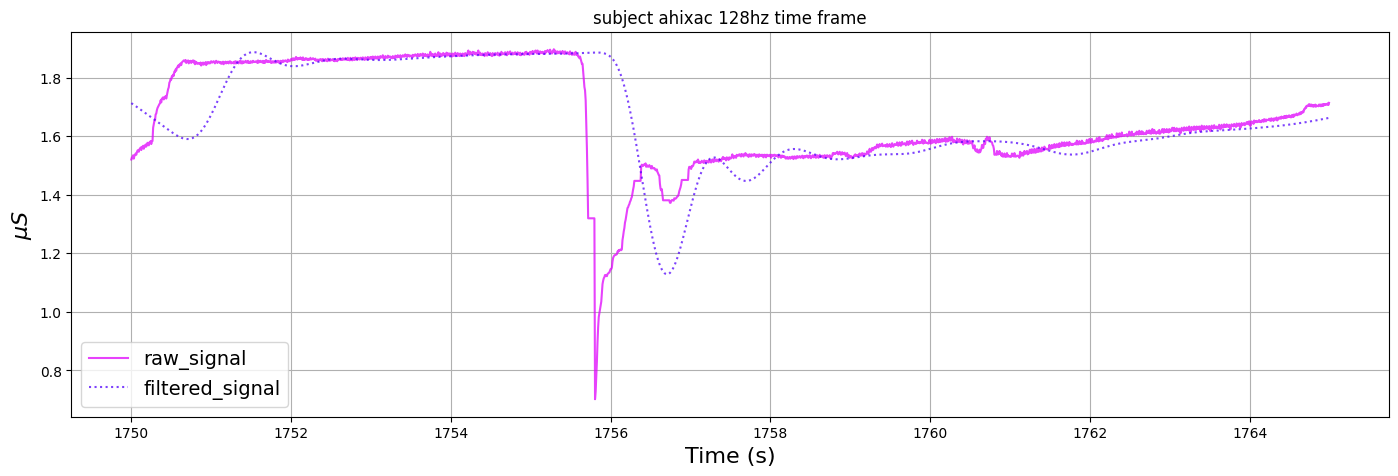

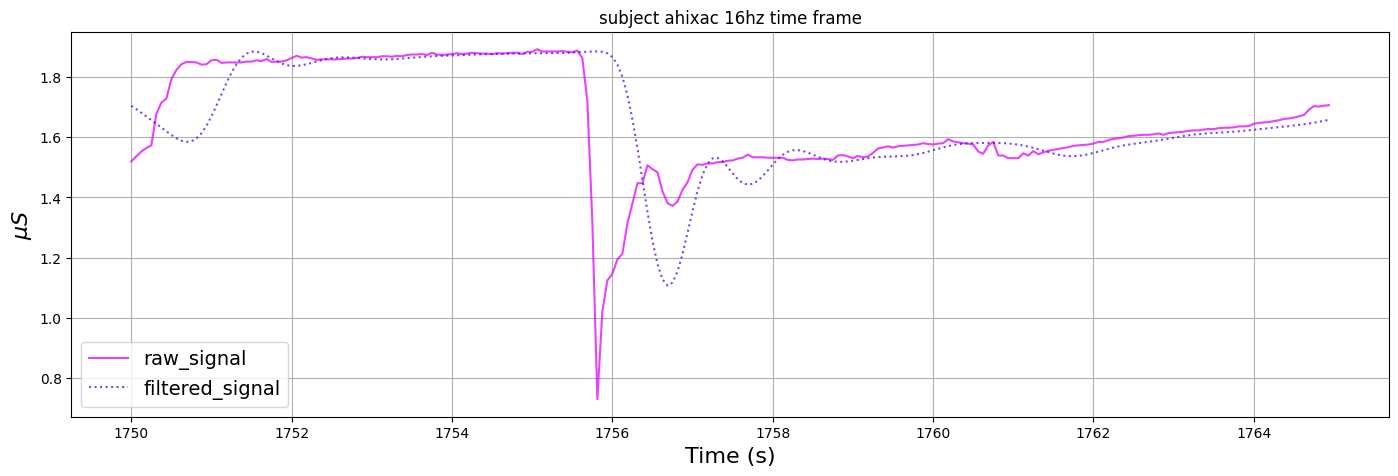

In [22]:
view_time_frame(ahixac_eda_df_128hz, samp_freq=128, cols_to_use=['raw_signal', 'filtered_signal'], img_title='subject ahixac 128hz time frame')
view_time_frame(ahixac_eda_df_16hz, samp_freq=16, cols_to_use=['raw_signal', 'filtered_signal'], img_title='subject ahixac 16hz time frame')

# Iterate through signals per hour

In [23]:
partition_signals_per_hour(ahixac_eda_df_128hz, hertz=128, window_size=0.5)

start: 0 | end: 460800
                                      time  raw_signal  clean_signal  label  \
1970-01-01 00:00:00.000000000     0.000000    0.000000     -0.164015    0.0   
1970-01-01 00:00:00.007812500     0.007812    0.000000     -0.127567    0.0   
1970-01-01 00:00:00.015625000     0.015625    0.000000     -0.127567    0.0   
1970-01-01 00:00:00.023437500     0.023438    0.000000     -0.127567    0.0   
1970-01-01 00:00:00.031250000     0.031250    0.000000     -0.127567    0.0   
...                                    ...         ...           ...    ...   
1970-01-01 00:59:59.960937500  3599.960938    1.482051      1.482051    0.0   
1970-01-01 00:59:59.968750000  3599.968750    1.484982      1.484982    0.0   
1970-01-01 00:59:59.976562500  3599.976562    1.499634      1.499634    0.0   
1970-01-01 00:59:59.984375000  3599.984375    1.477656      1.477656    0.0   
1970-01-01 00:59:59.992187500  3599.992188    1.487912      1.487912    0.0   

                            

In [24]:
partition_signals_per_hour(ahixac_eda_df_16hz, hertz=16, window_size=0.5)

start: 0 | end: 57600
                                 time  raw_signal  clean_signal  label  \
1970-01-01 00:00:00.000000     0.0000    0.000000     -0.164015    0.0   
1970-01-01 00:00:00.062500     0.0625    0.000000     -0.022974    0.0   
1970-01-01 00:00:00.125000     0.1250    0.000000     -0.022974    0.0   
1970-01-01 00:00:00.187500     0.1875    0.000000     -0.005128    0.0   
1970-01-01 00:00:00.250000     0.2500    0.000222      0.000222    0.0   
...                               ...         ...           ...    ...   
1970-01-01 00:59:59.687500  3599.6875    1.484982      1.484982    0.0   
1970-01-01 00:59:59.750000  3599.7500    1.483516      1.483516    0.0   
1970-01-01 00:59:59.812500  3599.8125    1.483516      1.483516    0.0   
1970-01-01 00:59:59.875000  3599.8750    1.483516      1.483516    0.0   
1970-01-01 00:59:59.937500  3599.9375    1.483516      1.483516    0.0   

                             auto_signal  pred_art  post_proc_pred_art  \
1970-01-01 00:0

In [21]:
# # once notebook reaches end remove data to clear space
# os.remove('./data/EDABE dataset.zip')
# os.remove('./data/Electrodermal Activity artifact correction BEnchmark (EDABE)')